In [13]:
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten,Embedding,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split

In [3]:
data=pd.read_csv("IMDB_Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
x=data["review"]
y=data["sentiment"]

y=y.map({
    "positive":1,
    "negative":0
})

# Tokenization
tokenizer=Tokenizer(num_words=5000)
#Learn vocabulary
tokenizer.fit_on_texts(x)
#Convert text to sequences
x=tokenizer.texts_to_sequences(x)

max_length=200
x=pad_sequences(x,maxlen=max_length)

x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.33, random_state=42)

In [7]:
print(x.shape)
print(y.shape)

(50000, 200)
(50000,)


In [15]:
model=Sequential()

#Input layer cannot take text it has to be embeddings
model.add(Embedding(input_dim=50000,output_dim=32,input_length=max_length))
model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1,activation="sigmoid"))

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
history=model.fit(
    x_train,
    y_train,
    epochs=10,
    verbose=1,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.6976 - loss: 0.5365 - val_accuracy: 0.8688 - val_loss: 0.3066
Epoch 2/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9209 - loss: 0.2037 - val_accuracy: 0.8622 - val_loss: 0.3607
Epoch 3/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9770 - loss: 0.0727 - val_accuracy: 0.8458 - val_loss: 0.5121
Epoch 4/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9875 - loss: 0.0385 - val_accuracy: 0.8467 - val_loss: 0.5929
Epoch 5/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9899 - loss: 0.0275 - val_accuracy: 0.8401 - val_loss: 0.7807
Epoch 6/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9947 - loss: 0.0162 - val_accuracy: 0.8461 - val_loss: 0.8832
Epoch 7/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9945 - loss: 0.0166 - val_accuracy: 0.8493 - val_loss: 0.8017
Epoch 8/10
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9954 -

In [19]:
loss,accuracy=model.evaluate(x_test,y_test)
print(loss)
print(accuracy)

prediction=model.predict(x_test[:5])
for i,pred in enumerate(prediction):
    if(pred>0.5):
        print(prediction[i],": Positive")
    else:
        print(prediction[i],": Negative")

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8467 - loss: 1.0430
1.0536812543869019
0.8480606079101562
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[0.00074379] : Negative
[0.9979993] : Positive
[5.89164e-06] : Negative
[1.] : Positive
[3.758304e-07] : Negative


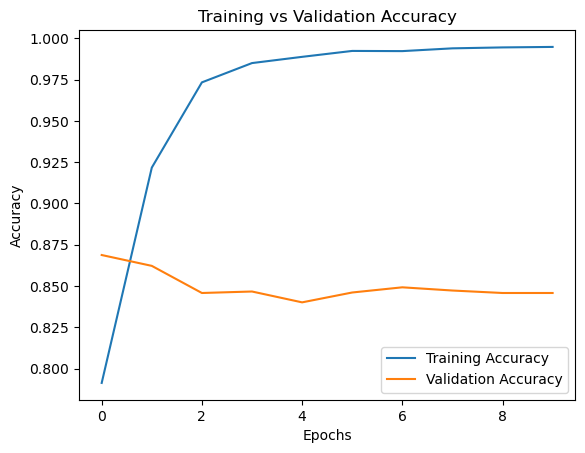

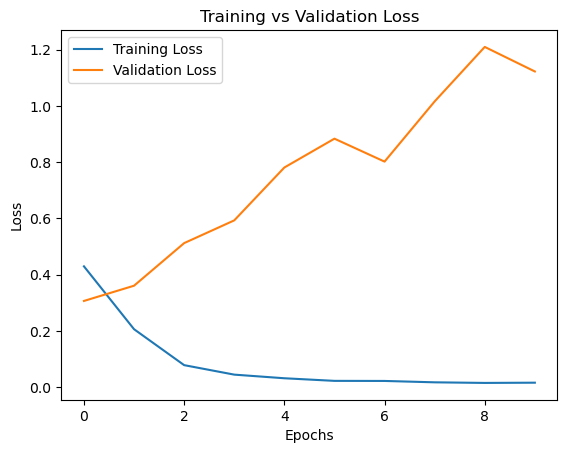

In [23]:
# A good model: both train & val accuracy go up and stay close together
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()